In [1]:
import ase
import numpy as np
import pyscf
import time
import os
from pyscf import gto, dft
from pyscf.scf import hf
hf.MUTE_CHKFILE = True
import equiv_dens.utils.base as utils
%load_ext autoreload
%autoreload 2

/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/pyscf/lib/misc.py:47: H5pyDeprecationWarning: Using default_file_mode other than 'r' is deprecated. Pass the mode to h5py.File() instead.
  h5py.get_config().default_file_mode = 'a'


Use "numpy" for Fourier Transform


In [6]:
positions = np.zeros((100, 2, 3))
for i in range(len(positions)):
    positions[i, 1, 0] = i/20 + 0.05
test_ind = np.array([i * 10 for i in range(10)])
valid_ind = test_ind + 5
train_ind = np.setdiff1d(np.arange(100), np.concatenate([test_ind, valid_ind]))
print('train', positions[train_ind])
print('valid', positions[valid_ind])
print('test_ind', test_ind)
atom_numbers = np.array([[1, 1]])

train [[[0.   0.   0.  ]
  [0.1  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.15 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.2  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.25 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.35 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.4  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.45 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.5  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.6  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.65 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.7  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.75 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.85 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.9  0.   0.  ]]

 [[0.   0.   0.  ]
  [0.95 0.   0.  ]]

 [[0.   0.   0.  ]
  [1.   0.   0.  ]]

 [[0.   0.   0.  ]
  [1.1  0.   0.  ]]

 [[0.   0.   0.  ]
  [1.15 0.   0.  ]]

 [[0.   0.   0.  ]
  [1.2  0.   0.  ]]

 [[0.   0.   0.  ]
  [1.25 0.   0.  ]]

 [[0.   0.   0.  ]
  [1.35 0.   0.  ]]

 [[0.   0.   0.  ]
  [1.4  0.   0.  ]]

 [[0.   0.   0.  ]
  [1.45 0.   0.  ]]

 [[0.   0.   0.  ]
  [1.5  0.   0.  ]]

 [[0.   0.   0.  ]
  [1.6  0.   0.

In [18]:
suffix = 'valid'
atom_pos = positions[valid_ind] 
atom_types = atom_numbers.squeeze()
atoms = {'atom_numbers': atom_types, 'positions': atom_pos, 'atom_types': ['H', 'H']}
np.save('datasets/H2_basic_' + suffix + '.npy', atoms, allow_pickle=True)
basis = 'ccpvdz'
save_path = 'datasets/H2_pyscf_' + basis + '_dft_' + suffix + '.npy'
#if os.path.exists(save_path):
#    results = list(np.load(save_path, allow_pickle=True))
#else:
results = []
print('results len', len(results))
for i in range(len(results), len(atom_pos)):
    print('calc', i)
    start = time.time()
    pos = atom_pos[i]
    atom = []
    for j in range(len(atom_types)):
        atom.append((atom_types[j], pos[j, :])) 
    print('atom', atom)
    mol = gto.M(atom=atom, basis=basis)
    #print(mol.pack())
    mf = dft.RKS(mol)
    mf.chkfile=False
    mf.xc = 'lda'
    #mf.max_cycle = 1000
    mf.kernel()
    g = mf.nuc_grad_method()
    forces = g.grad()
    print('elapsed', time.time() - start)
    #print(mfs[i].mo_coeff)
    res = []
    res.append(mol.pack())
    calc_dict = {}
    vhf = mf.get_veff()
    print('exchange energy', vhf.exc)
    print('SCF summary', mf.scf_summary)
    print('mo occ', mf.mo_occ)
    calc_dict['mo_coeff'] = mf.mo_coeff
    calc_dict['mo_occ'] = mf.mo_occ
    calc_dict['energy'] = mf.e_tot
    calc_dict['ex_energy'] = vhf.exc
    calc_dict['forces'] = forces
    res.append(calc_dict)
    results.append(res)
    
    if i%10 == 0:
        np.save(save_path, results, allow_pickle=True)
np.save(save_path, results, allow_pickle=True)

results len 0
calc 0
atom [(1, array([0., 0., 0.])), (1, array([0.3, 0. , 0. ]))]
converged SCF energy = -0.490733240997499
--------------- RKS gradients ---------------
         x                y                z
0 H     2.4032227626     0.0000000000    -0.0000000000
1 H    -2.4032227626     0.0000000000     0.0000000000
----------------------------------------------
elapsed 0.0747365951538086
exchange energy -0.6972030607629194
SCF summary {'e1': -3.1906323473885356, 'coul': 1.6331781307539561, 'exc': -0.6972030607629196, 'nuc': 1.7639240364000002}
mo occ [2. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
calc 1
atom [(1, array([0., 0., 0.])), (1, array([0.8, 0. , 0. ]))]
converged SCF energy = -1.03927823855788
--------------- RKS gradients ---------------
         x                y                z
0 H    -0.0011231486     0.0000000000     0.0000000000
1 H     0.0011231486     0.0000000000    -0.0000000000
----------------------------------------------
elapsed 0.0760030746459961
exchange energy -0.

In [23]:
data_modes = ['train', 'test', 'valid']
for dmode in data_modes: 
    np_path = 'datasets/H2_basic_' + dmode + '.npy'
    pyscf_path = 'datasets/H2_pyscf_' + basis + '_dft_' + dmode + '.npy'
    
    np_data = np.load(np_path, allow_pickle=True).item()
    pyscf_data = np.load(pyscf_path, allow_pickle=True)
    
    np_data['energy'] = []
    np_data['forces'] = []
    for calc in pyscf_data:
        np_data['energy'].append(calc[1]['ex_energy'])
        np_data['forces'].append(-calc[1]['forces'] * utils.to_bohr)

    np_data['energy'] = np.array(np_data['energy'])[:, None]
    np_data['forces'] = np.array(np_data['forces'])
    print('energy shape', np_data['energy'].shape)
    print('forces shape', np_data['forces'].shape)
    np.save(np_path, np_data, allow_pickle=True)

energy shape (80, 1)
forces shape (80, 2, 3)
energy shape (10, 1)
forces shape (10, 2, 3)
energy shape (10, 1)
forces shape (10, 2, 3)


[0.1  0.15 0.2  0.25 0.35 0.4  0.45 0.5  0.6  0.65 0.7  0.75 0.85 0.9
 0.95 1.   1.1  1.15 1.2  1.25 1.35 1.4  1.45 1.5  1.6  1.65 1.7  1.75
 1.85 1.9  1.95 2.   2.1  2.15 2.2  2.25 2.35 2.4  2.45 2.5  2.6  2.65
 2.7  2.75 2.85 2.9  2.95 3.   3.1  3.15 3.2  3.25 3.35 3.4  3.45 3.5
 3.6  3.65 3.7  3.75 3.85 3.9  3.95 4.   4.1  4.15 4.2  4.25 4.35 4.4
 4.45 4.5  4.6  4.65 4.7  4.75 4.85 4.9  4.95 5.  ]


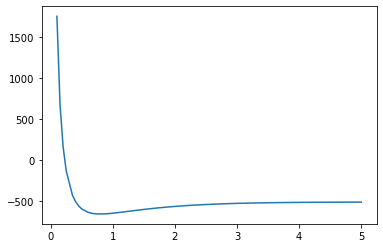

304.115350667084
[0.05 0.55 1.05 1.55 2.05 2.55 3.05 3.55 4.05 4.55]


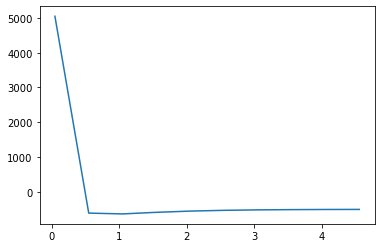

1682.39006431133
[0.3 0.8 1.3 1.8 2.3 2.8 3.3 3.8 4.3 4.8]


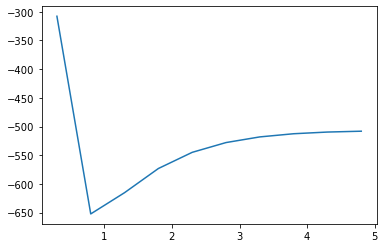

86.50966237761929


In [20]:
import matplotlib.pyplot as plt

data_modes = ['train', 'test', 'valid']
for dmode in data_modes: 
    np_path = 'datasets/H2_basic_' + dmode + '.npy'
    np_data = np.load(np_path, allow_pickle=True).item()
    plt.figure()
    dists = np.sqrt(np.sum((np_data['positions'][:, 0, :] - np_data['positions'][:, 1, :])**2, axis=-1))
    print(dists)
    plt.plot(dists, np_data['energy'] * 627.59)
    plt.show()
    print(np.std(np_data['energy'] * 627.59))
    

In [ ]:
--restart=2022-06-09_Q1CyzdFf -- h2 total energy with forces

2022-06-09_dP4N2ydE -- h2 exc energy with distance info 
2022-06-09_oDQAf01s -- h2 exc energy without distance info;


In [3]:
dmode = 'train'
basis = 'ccpvdz'
np_path = 'datasets/H2_basic_' + dmode + '.npy'
pyscf_path = 'datasets/H2_pyscf_' + basis + '_dft_' + dmode + '.npy'


In [48]:
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
import torch
from functools import partial
from equiv_dens.training.errors import ErrorDict
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.data.hamiltonian_dataset import seeded_random_split
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    dftpy_grid, CubicalGrid, spherical_grid, spherical_radial_sampling
from equiv_dens.training.model_loader import load_model
import equiv_dens.utils.base as utils


args, hyperparam_args = parse_command_line_arguments(arg_file='h2_partial_en_only.txt')
print('type dtype', type(args.dtype))
print('args np dir', args.np_dataset)
# no restart directory specified
args.fix_arguments = True
args.restart = '2022-06-09_Q1CyzdFf'
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")
args.use_gpu = False
if args.cube_grid:
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

dataset = AtomsDensityData(np_path=args.np_dataset_test, density_path=args.dens_dataset_test,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'energy'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=args.verbose)
torch.manual_seed(0)
np.random.seed(0)
#args.restart = None
args.density_weight = 0
data_split_indices = checkpoint['data_split_indices']
print(data_split_indices)
print('energy model', args.energy_model)
if args.center_energy:
    train_data = np.load(args.np_dataset, allow_pickle=True).item()
    energy_mean = np.mean(train_data['energy'])
    dataset.center_energy(energy_mean)


model = load_model(args, dataset)

type dtype <class 'torch.dtype'>
args np dir datasets/H2_basic_test.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperparam arg 

In [48]:
print(len(pyscf_data))

10


results energy tensor([[ 2.2565e+03],
        [ 1.1863e+03],
        [ 6.7703e+02],
        [ 3.8943e+02],
        [ 8.2043e+01],
        [-7.6294e-01],
        [-5.7220e+01],
        [-9.3110e+01],
        [-1.3467e+02],
        [-1.4539e+02]])
results energy tensor([[-151.8703],
        [-155.1699],
        [-155.3616],
        [-153.3484],
        [-150.4160],
        [-146.8149],
        [-138.3660],
        [-133.8116],
        [-129.1762],
        [-124.5240]])
results energy tensor([[-115.3224],
        [-110.8259],
        [-106.4277],
        [-102.1444],
        [ -93.9695],
        [ -90.0966],
        [ -86.3777],
        [ -82.8186],
        [ -76.1840],
        [ -73.0955]])
results energy tensor([[-70.1412],
        [-67.3077],
        [-61.9887],
        [-59.5069],
        [-57.1439],
        [-54.8970],
        [-50.7328],
        [-48.8052],
        [-46.9737],
        [-45.2333]])
results energy tensor([[-42.0064],
        [-40.5113],
        [-39.0901],
        [-3

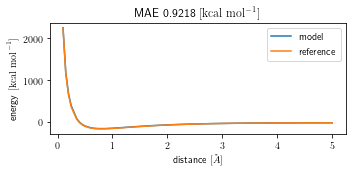

In [51]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

model.eval()
distances = torch.tensor([]).view(0, 1)
energies = torch.tensor([]).view(0, 1)
energy_ref = torch.tensor([]).view(0, 1)
figure = plt.figure(figsize=(5, 2.5))
for i in range(int(len(dataset)/10)):
    inds = np.arange(i * 10, i*10 + 10)
    samples = dataset.get_properties(inds)
    results = model(samples)
    distances = torch.cat([distances, torch.sqrt(torch.sum((results['positions'][:, 0, :] - results['positions'][:, 1, :])**2, axis=-1, keepdim=True))], dim=0)
    print('results energy', results['energy'])
    energies = torch.cat([energies, results['energy']])
    energy_ref = torch.cat([energy_ref, samples['energy']])

distances = distances.numpy()
plt.plot(distances, energies, label='model')

#get training mean
energy_ref = [] 
dmode = 'train'
basis = 'ccpvdz'
np_path = 'datasets/H2_basic_' + dmode + '.npy'
pyscf_path = 'datasets/H2_pyscf_' + basis + '_dft_' + dmode + '.npy'
pyscf_data = np.load(pyscf_path, allow_pickle=True)

for calc in pyscf_data:
    en = calc[1]['energy']
    energy_ref.append(en)
energy_ref = torch.tensor(energy_ref).view(-1, 1) 
energy_ref = energy_ref - torch.mean(energy_ref)

energy_ref = utils.hartree_to_kcal(energy_ref)
plt.plot(distances, energy_ref, label='reference')
print('MAE', torch.mean(torch.abs(energies - energy_ref)))
plt.title(r'MAE ' + '{:.4f}'.format(float(torch.median(torch.abs(energies - energy_ref)))) + ' $[\mathrm{kcal\ mol}^{-1}]$')
plt.legend()
plt.xlabel(r'distance $[\AA]$')
plt.ylabel(r'energy $[\mathrm{kcal\ mol}^{-1}]$')
plt.tight_layout()
plt.savefig('figures/total_model_dist.pdf', dpi=300)
plt.show()